### This example shows how to use the continuous-wave (cw) `fcon.py` function to generate the efficieny of frequency conversion in nonlinear waveguides. These are valid for *arbitrary dispersion*. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from NeedALight.fcon import Fcw

In the CW limit, the Heisenberg propagator reduces to a (2 x 2) matrix for each frequency value. In this case, we can produce the Bloch-Messiah decomposition analytically. We find that the propagator is
\begin{align}
    K=\begin{pmatrix}
			K^{S,S} & K^{S,I}\\
			K^{I,S} & K^{I,I}
		\end{pmatrix}
\end{align}
where
\begin{align}
    K^{S,S}&= e^{i\Sigma_{K}(\omega) z/2}\left[ \cos\left(\nu(\omega)z/2\right) -i\frac{\Delta K(\omega)}{\nu(\omega)}\sin\left(\nu(\omega)z/2\right)    \right], \\
    K^{S,I}&=K^{I,S}=\frac{2i\gamma e^{i\Sigma_{K}(\omega) z/2}\sin\left(\nu(\omega)z/2\right)}{\nu(\omega)} , \\
    K^{I,I}&= e^{i\Sigma_{K}(\omega) z/2}\left[ \cos\left(\nu(\omega)z/2\right) +i\frac{\Delta K(\omega)}{\nu(\omega)}\sin\left(\nu(\omega)z/2\right)    \right] ,\\
\end{align}
and where we have defined
\begin{align}
    \Delta K(\omega) &= \Delta k_{I}(\omega)-\Delta k_{S}(\omega),\\
    \Sigma_{K}(\omega) &= \Delta k_{I}(\omega)+\Delta k_{S}(\omega),. \\
    \nu(\omega)& = \sqrt{\left[\Delta K(\omega)\right]^2+4\gamma^2}.
\end{align}

The Bloch-Messiah decomposition tells us that $K^{S,S}\left[K^{S,S}   \right]^{*}=\cos^{2}(\theta)$ and $K^{S,I}\left[K^{S,I}   \right]^{*}=\sin^{2}(\theta)$. From this we can identify the transmission/reflection(efficiency) coefficients as
\begin{align}
    \cos^{2}(\theta(\omega)) &= \frac{4\gamma^{2}\cos^{2}(\nu(\omega)z/2)+\left[\Delta K(\omega)\right]^{2}}{\nu^{2}(\omega)},  \\
    \sin^{2}(\theta(\omega)) &= \frac{4\gamma^{2}\sin^{2}(\nu(\omega)z/2)}{\nu^{2}(\omega)}.
\end{align}

To actually obtain the Bloch-Messiah decomposion, by expressing things in polar-form we can re-write the propagator as 
\begin{align}
    K = \frac{2\gamma e^{i\Sigma_{K}(\omega) z/2}}{\nu(\omega)}\begin{pmatrix}
        \sqrt{\cos^{2}(\nu(\omega)z/2)+\left(\frac{\Delta K(\omega)}{2\gamma}\right)^2}e^{-i\Psi}& i\sin(\nu(\omega)z/2)\\
        i\sin(\nu(\omega)z/2) & \sqrt{\cos^{2}(\nu(\omega)z/2)+\left(\frac{\Delta K(\omega)}{2\gamma}\right)^2}e^{i\Psi}
    \end{pmatrix}
\end{align}
where $\Psi = \tan^{-1}\left[\frac{\Delta K(\omega)}{\nu(\omega)} \tan(\nu(\omega)z/2)   \right]$. In this form we can then break it down such that
\begin{align}
    K =& e^{i\Sigma_{K}(\omega) z/2}\begin{pmatrix}
			e^{i\Psi} & 0\\
			0 & i
		\end{pmatrix}\begin{pmatrix}
        \frac{2\gamma}{\nu(\omega)}\sqrt{\cos^{2}(\nu(\omega)z/2)+\left(\frac{\Delta K(\omega)}{2\gamma}\right)^2}& -\frac{2\gamma}{\nu(\omega)}\sin(\nu(\omega)z/2)\\
        \frac{2\gamma}{\nu(\omega)}\sin(\nu(\omega)z/2) & \frac{2\gamma}{\nu(\omega)}\sqrt{\cos^{2}(\nu(\omega)z/2)+\left(\frac{\Delta K(\omega)}{2\gamma}\right)^2}
    \end{pmatrix}
    \begin{pmatrix}
			1 & 0\\
			0 & -ie^{-i\Psi}
		\end{pmatrix}
\end{align}

The built in function *does not* use the analytic expression, but rather does the Bloch-Messiah numerically (using the `cossin` `scipy.linalg` function) for each frequency-value. From the decomposition, we see that the input and output modes are just phases. These are uninteresting and are therefore not output by the function. In fact, the `Fcw` function only outputs the Efficiency.

Initializing all relevant quantities needed to use the functions and generate the wanted properties.

In [8]:
#Parameters for calculations
N = 301  # Number of frequency values
l = 1.0  # amplification region length

#Dispersions
v = 0.1  #velocity of all modes
b = 3    #group-velocity dispersion
ts =0.09   #signal cubic term
ti =0.07   #idler cubic term 
#Frequency values
wi = -10
wf = 10
w = np.linspace(wi, wf, N)
dw = np.abs(w[1]-w[0])
#Dispersion relations
ks = w/v+b*w**2 + ts*w**3
ki = w/v+b*w**2 + ti*w**3


#Interaction strength
Np = 1.72e-3 # Number of pump photons: Vary this to modify gain values
gamma = np.sqrt(Np)/np.sqrt(2 * np.pi * v**3)

First we show the phase-mismatch. We include two sets of horizontal lines which correspond to the values at which the phase-matching function $(\Phi = \text{sinc}(\Delta k(\omega)l/2))$ reaches its first zero for two values of the interaction strength.

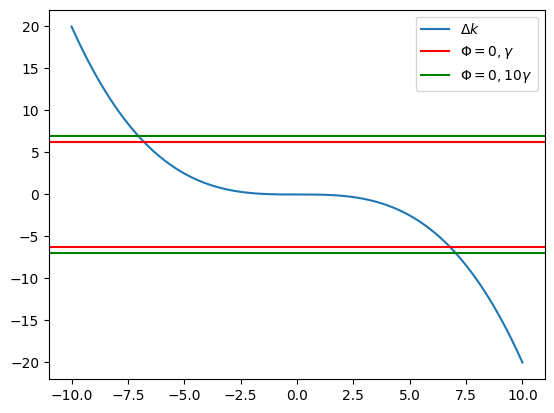

In [24]:
#Might need to change the pi coefficient depending on interaction strength
plt.plot(w, -ks+ki, label = r"$\Delta k$")
plt.axhline(np.sqrt((2 * np.pi / l) ** 2 - 4 * (gamma) ** 2), color="r",label=r"$\Phi = 0,\gamma$")
plt.axhline(-np.sqrt((2 * np.pi / l) ** 2 - 4 * (gamma) ** 2), color="r")
plt.axhline(np.sqrt((4 * np.pi / l) ** 2 - 4 * (10 * gamma) ** 2),color="g",label=r"$\Phi = 0,10\gamma$")
plt.axhline(-np.sqrt((4 * np.pi / l) ** 2 - 4 * (10 * gamma) ** 2),color="g")
plt.legend()
plt.show()

Obtaining the Efficiency from the `Fcw` function for two levels of pump strength.

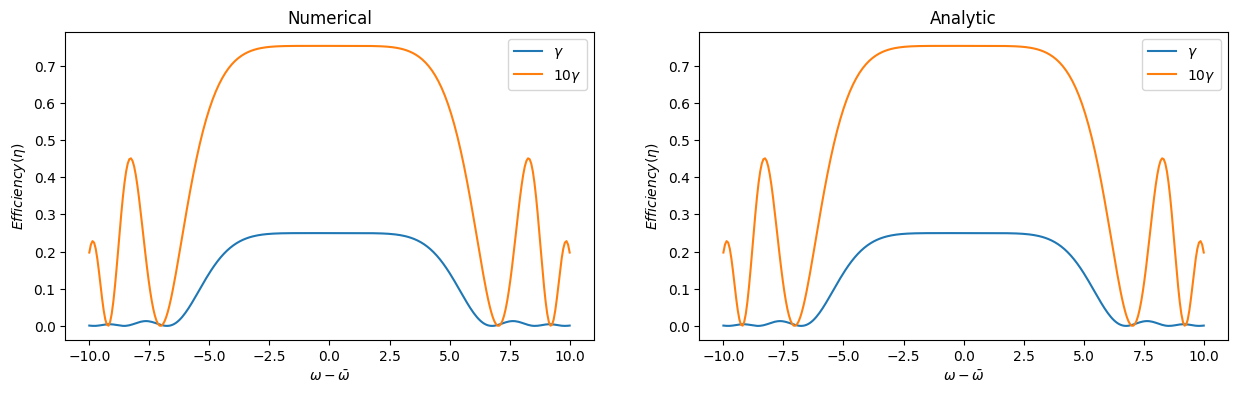

Do the numerical and analytic efficiencies agree?(Low, High): (True, True)


In [22]:
Eff_l = Fcw(ks,ki,gamma,l)
Eff_h = Fcw(ks,ki,10*gamma,l)

Analytic_l = 4*gamma**2*np.sin(np.sqrt((ki-ks)**2 +4*gamma**2)*l/2)**2/np.sqrt((ki-ks)**2 +4*gamma**2)**2
Analytic_h = 4*(10*gamma)**2*np.sin(np.sqrt((ki-ks)**2 +4*(10*gamma)**2)*l/2)**2/np.sqrt((ki-ks)**2 +4*(10*gamma)**2)**2

fig, ax = plt.subplots(1,2, figsize=(15,4))


ax[0].plot(w,Eff_l, label = r"$\gamma$")
ax[0].plot(w,Eff_h, label = r"$10\gamma$")
ax[0].set_xlabel(r"$\omega-\bar{\omega}$")
ax[0].set_ylabel(r"$Efficiency (\eta)$")
ax[0].set_title('Numerical')
ax[0].legend()

ax[1].plot(w,Analytic_l, label = r"$\gamma$")
ax[1].plot(w,Analytic_h, label = r"$10\gamma$")
ax[1].set_xlabel(r"$\omega-\bar{\omega}$")
ax[1].set_ylabel(r"$Efficiency (\eta)$")
ax[1].set_title('Analytic')
ax[1].legend()


plt.show()

print(f'Do the numerical and analytic efficiencies agree?(Low, High): {np.allclose(Eff_l, Analytic_l), np.allclose(Eff_h, Analytic_h)}')

Note that we also observe a slight spectral broadening.